# CLASIFICACIÓN

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')

# ── Carga desde HuggingFace ───────────────────────────────────────────────────
raw = load_dataset('YominE/Muscle_Fatigue_Cycling')
df  = raw['train'].to_pandas()

print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())
print('\nPrimeras filas:')
df.head()

Shape: (3002137, 10)
Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Primeras filas:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [6]:
CHANNELS = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]

# Convertir solo las columnas que necesitamos, más eficiente
df = raw['train'].to_pandas()

# Binarizar con numpy directamente, mucho más rápido
df['Target'] = np.where(df['Target'] == 2, 1, df['Target'])

print('Target DESPUÉS:')
print(df['Target'].value_counts().sort_index())

Target DESPUÉS:
Target
0    2127600
1     874537
Name: count, dtype: int64


In [4]:
print('=== Tipos de variables ===\n')
print(df.dtypes)
print('\n=== Estadísticos descriptivos ===\n')
df.describe()

=== Tipos de variables ===

Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

=== Estadísticos descriptivos ===



,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
count,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06
mean,6.385404e+02,3.818719e-10,-5.484116e-09,1.607046e-08,6.232624e-09,2.408926e-08,-2.482363e-08,4.634169e-10,-5.008274e-08,2.913048e-01
std,4.855156e+02,4.322670e-02,2.126250e-02,4.680434e-02,3.235313e-02,4.256358e-02,7.176269e-02,5.702359e-02,5.926507e-02,4.543637e-01
min,0.000000e+00,-8.433421e-01,-1.117295e+00,-1.749318e+00,-1.575973e+00,-7.503011e-01,-1.216622e+00,-1.304432e+00,-1.199719e+00,0.000000e+00
25%,2.501780e+02,-9.712520e-03,-3.884910e-03,-8.921014e-03,-6.285701e-03,-8.235582e-03,-9.509088e-03,-1.332585e-02,-1.391587e-02,0.000000e+00
50%,5.003560e+02,4.047832e-05,-1.482451e-05,9.786492e-05,-1.267264e-04,1.626615e-04,1.187206e-04,-1.495369e-04,6.502335e-04,0.000000e+00
75%,9.910640e+02,1.018903e-02,3.919922e-03,9.312195e-03,6.089190e-03,9.009457e-03,1.112872e-02,1.315710e-02,1.687481e-02,1.000000e+00
max,1.741598e+03,9.920845e-01,1.063230e+00,1.614778e+00,8.685851e-01,8.429890e-01,1.079527e+00,1.336625e+00,9.400506e-01,1.000000e+00


## 1b. Clasificación de variables

| Variable | Tipo | Rol |
|---|---|---|
| Time | Numérica continua | Descartada — correlación lineal directa con target |
| Right Rectus femoris | Numérica continua | Feature (señal EMG) |
| Left Gluteus maximus | Numérica continua | Feature (señal EMG) |
| Left Gastrocnemius medialis | Numérica continua | Feature (señal EMG) |
| Left Semitendinosus | Numérica continua | Feature (señal EMG) |
| Left Biceps femoris caput longus | Numérica continua | Feature (señal EMG) |
| Right Vastus medialis | Numérica continua | Feature (señal EMG) |
| Right Tibialis anterior | Numérica continua | Feature (señal EMG) |
| Left Gastrocnemius lateralis | Numérica continua | Feature (señal EMG) |
| Target | Binaria (0/1) | Variable objetivo |

## Feauture Engineering

In [7]:
from scipy.signal import welch

FS          = 1000
WINDOW_SIZE = FS
N_WINDOWS   = len(df) // WINDOW_SIZE

print(f'Total muestras : {len(df):,}')
print(f'Ventanas de 1s : {N_WINDOWS:,}')

def extraer_caracteristicas(ventana, fs=1000):
    # Dominio del tiempo
    rms      = np.sqrt(np.mean(ventana ** 2))
    varianza = np.var(ventana)
    zcr      = int(np.sum(np.diff(np.sign(ventana)) != 0))
    mav      = np.mean(np.abs(ventana))

    # Dominio de la frecuencia
    freqs, psd   = welch(ventana, fs=fs)
    pot_total    = np.sum(psd)
    frec_media   = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
    pot_acum     = np.cumsum(psd)
    idx_median   = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[min(idx_median, len(freqs) - 1)]

    return rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana

FEAT_NAMES = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

filas = []
for i in range(N_WINDOWS):
    inicio     = i * WINDOW_SIZE
    fin        = inicio + WINDOW_SIZE
    ventana_df = df.iloc[inicio:fin]
    fila       = {}

    for canal in CHANNELS:
        feats = extraer_caracteristicas(ventana_df[canal].values, fs=FS)
        for nombre, valor in zip(FEAT_NAMES, feats):
            fila[f'{canal}_{nombre}'] = valor

    fila['target'] = int(ventana_df['Target'].mode()[0])
    filas.append(fila)

nuevo_df = pd.DataFrame(filas)

# Guardar — este sí es pequeño, instantáneo
nuevo_df.to_csv('data/nuevo_dataset.csv', index=False)

print(f'\nNuevo dataset: {nuevo_df.shape}')
print(f'Features por fila: {nuevo_df.shape[1] - 1}')
nuevo_df.head()

Total muestras : 3,002,137
Ventanas de 1s : 3,002

Nuevo dataset: (3002, 57)
Features por fila: 56


,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana,target
0,0.011706,0.000137,123,0.008125,0.000037,54.570838,50.78125,0.003989,0.000016,122,...,90.848193,93.75000,0.025655,0.000658,120,0.019441,0.000127,59.538860,50.78125,0
1,0.014023,0.000197,111,0.010118,0.000045,55.855994,54.68750,0.004223,0.000018,120,...,86.074708,82.03125,0.031409,0.000986,149,0.021678,0.000294,79.432906,78.12500,0
2,0.014820,0.000220,121,0.010151,0.000051,54.184636,46.87500,0.004209,0.000018,126,...,85.845205,85.93750,0.026209,0.000687,101,0.020389,0.000219,58.352164,54.68750,0
3,0.013817,0.000191,121,0.009894,0.000053,57.536177,46.87500,0.004374,0.000019,115,...,86.521514,85.93750,0.021673,0.000470,154,0.015846,0.000133,86.660432,93.75000,0
4,0.013326,0.000177,122,0.009676,0.000045,58.618735,46.87500,0.004641,0.000022,120,...,88.026779,93.75000,0.025220,0.000636,138,0.019283,0.000181,76.983961,78.12500,0


In [8]:
nuevo_df.to_csv('data/nuevo_dataset.csv', index=False)
print('Guardado en data/nuevo_dataset.csv')

Guardado en data/nuevo_dataset.csv


In [10]:
# Para futuras sesiones
nuevo_df = pd.read_csv('data/nuevo_dataset.csv')
nuevo_df.head()

,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana,target
0,0.011706,0.000137,123,0.008125,0.000037,54.570838,50.78125,0.003989,0.000016,122,...,90.848193,93.75000,0.025655,0.000658,120,0.019441,0.000127,59.538860,50.78125,0
1,0.014023,0.000197,111,0.010118,0.000045,55.855994,54.68750,0.004223,0.000018,120,...,86.074708,82.03125,0.031409,0.000986,149,0.021678,0.000294,79.432906,78.12500,0
2,0.014820,0.000220,121,0.010151,0.000051,54.184636,46.87500,0.004209,0.000018,126,...,85.845205,85.93750,0.026209,0.000687,101,0.020389,0.000219,58.352164,54.68750,0
3,0.013817,0.000191,121,0.009894,0.000053,57.536177,46.87500,0.004374,0.000019,115,...,86.521514,85.93750,0.021673,0.000470,154,0.015846,0.000133,86.660432,93.75000,0
4,0.013326,0.000177,122,0.009676,0.000045,58.618735,46.87500,0.004641,0.000022,120,...,88.026779,93.75000,0.025220,0.000636,138,0.019283,0.000181,76.983961,78.12500,0


## EDA


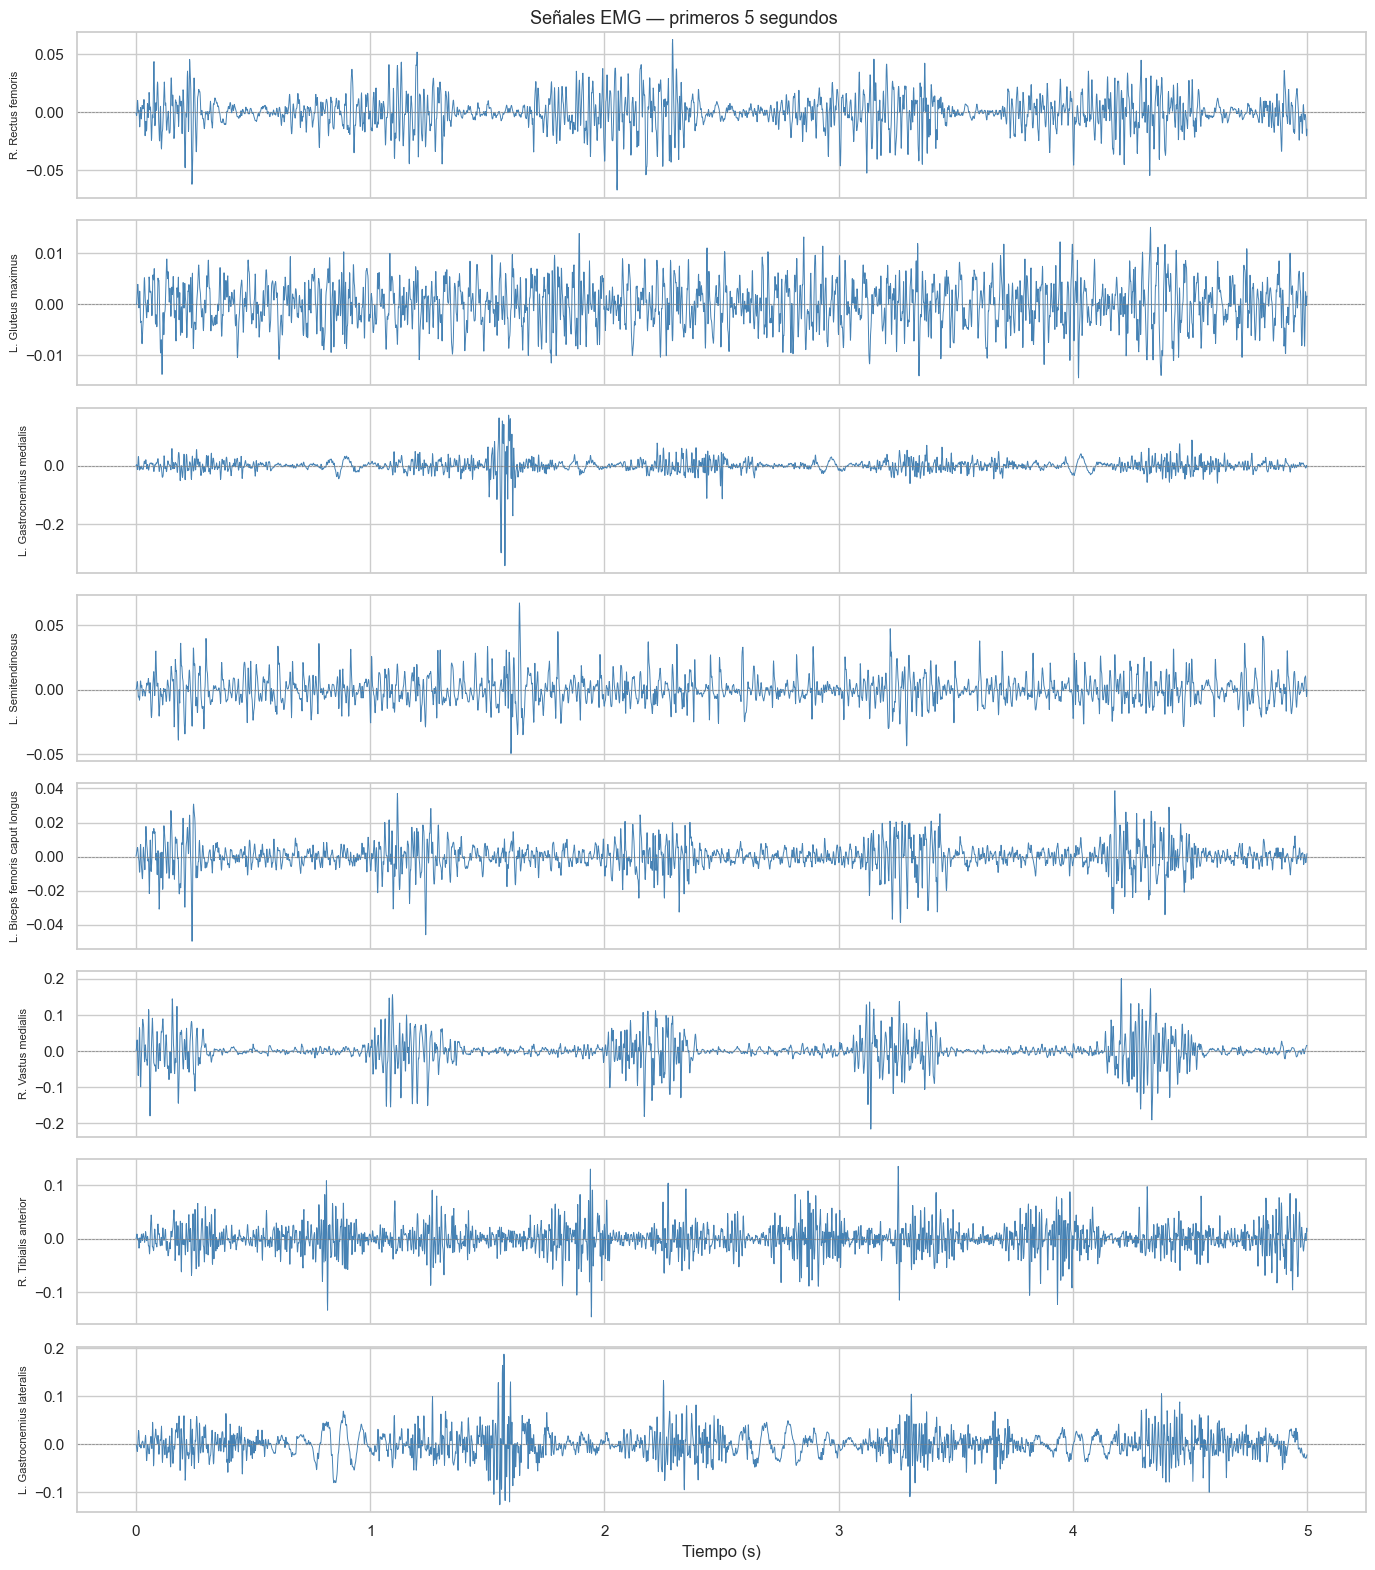

In [11]:
# 3a. Graficar porción de señales en el tiempo
fig, axes = plt.subplots(8, 1, figsize=(14, 16), sharex=True)

n_muestra = 5000  # primeros 5 segundos

for ax, canal in zip(axes, CHANNELS):
    ax.plot(df['Time'].iloc[:n_muestra], 
            df[canal].iloc[:n_muestra], 
            lw=0.7, color='steelblue')
    ax.set_ylabel(canal.replace('Left ', 'L. ').replace('Right ', 'R. '), 
                  fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, linestyle='--')

axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EMG — primeros 5 segundos', fontsize=13)
plt.tight_layout()
plt.show()

### Conclusiones iniciales sobre el dataset (punto 3a)

1. **Señales centradas en cero:** todos los canales oscilan simétricamente 
   alrededor de 0, lo que indica que la señal EMG está correctamente 
   preprocesada y sin offset DC.

2. **Amplitudes heterogéneas entre músculos:** canales como L. Gastrocnemius 
   medialis y L. Gastrocnemius lateralis muestran picos esporádicos de alta 
   amplitud (±0.2 a ±0.3), mientras que L. Gluteus maximus tiene amplitudes 
   mucho más pequeñas (±0.01). Esto refleja diferencias reales en el nivel de 
   activación muscular durante el sprint.

3. **Comportamiento no estacionario:** la amplitud y densidad de las 
   oscilaciones varía a lo largo del tiempo incluso en estos primeros 5 
   segundos, lo que justifica el uso de ventanas de 1 segundo para capturar 
   el comportamiento local de cada músculo.

4. **Artefactos de movimiento:** los picos abruptos aislados (ej. segundo 2 
   en L. Gastrocnemius medialis) pueden corresponder a artefactos de 
   movimiento del electrodo, no a actividad muscular real.

5. **Alta frecuencia de muestreo confirmada:** la densidad de las oscilaciones 
   es consistente con 1000 Hz, validando el parámetro FS = 1000 usado en el 
   feature engineering.

## Balance de Clases


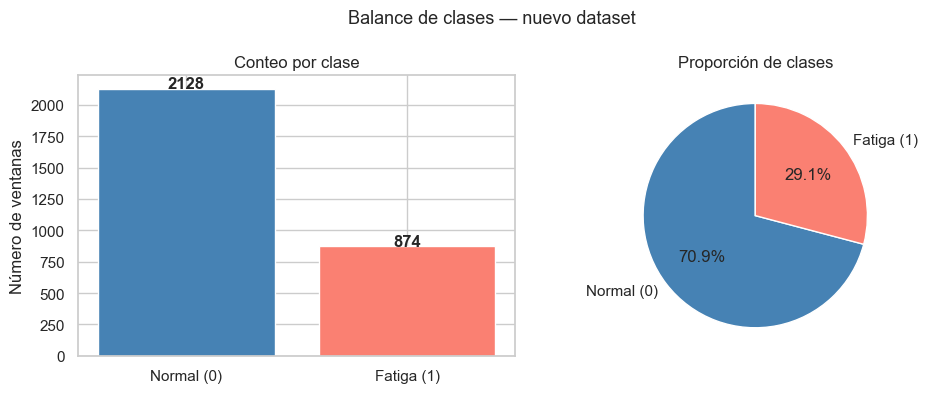

target
0    2128
1     874
Name: count, dtype: int64


In [12]:
# Balance de clases
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

clase_counts = nuevo_df['target'].value_counts().sort_index()
porcentajes  = clase_counts / len(nuevo_df) * 100

# Barplot
axes[0].bar(['Normal (0)', 'Fatiga (1)'], clase_counts.values, 
            color=['steelblue', 'salmon'])
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Número de ventanas')
for i, v in enumerate(clase_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(clase_counts.values, labels=['Normal (0)', 'Fatiga (1)'],
            colors=['steelblue', 'salmon'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')

fig.suptitle('Balance de clases — nuevo dataset', fontsize=13)
plt.tight_layout()
plt.show()

print(clase_counts)

In [13]:
# Estadísticos descriptivos del nuevo dataset
print('=== Estadísticos descriptivos ===\n')
nuevo_df.describe().T

=== Estadísticos descriptivos ===



,count,mean,std,min,25%,50%,75%,max
Right Rectus femoris_rms,3002.0,0.035700,0.024379,0.002970,0.021569,0.029745,0.042171,0.190683
Right Rectus femoris_var,3002.0,0.001869,0.003613,0.000009,0.000465,0.000885,0.001778,0.036360
Right Rectus femoris_zcr,3002.0,108.874084,13.094489,63.000000,100.000000,109.000000,118.000000,155.000000
Right Rectus femoris_mav,3002.0,0.022596,0.015262,0.002243,0.013461,0.018516,0.026945,0.128436
Right Rectus femoris_pot,3002.0,0.000483,0.000982,0.000002,0.000099,0.000223,0.000444,0.011503
Right Rectus femoris_f_media,3002.0,54.015740,6.264138,20.487091,50.660325,54.555808,58.067109,71.694238
Right Rectus femoris_f_mediana,3002.0,47.493078,8.368634,15.625000,42.968750,46.875000,50.781250,74.218750
Left Gluteus maximus_rms,3002.0,0.011715,0.017748,0.002799,0.005364,0.007019,0.010890,0.196428
Left Gluteus maximus_var,3002.0,0.000452,0.002460,0.000008,0.000029,0.000049,0.000119,0.038583
Left Gluteus maximus_zcr,3002.0,120.347435,17.927588,45.000000,110.000000,122.000000,133.000000,174.000000


### Observaciones clave:

Sin valores nulos — count = 3002 en todas las features

Sin valores extremos raros — rangos coherentes con señales EMG

ZCR varía entre ~45 y ~214 cruces por segundo según el músculo

Frecuencias entre 15 y 125 Hz — rango fisiológico normal para EMG

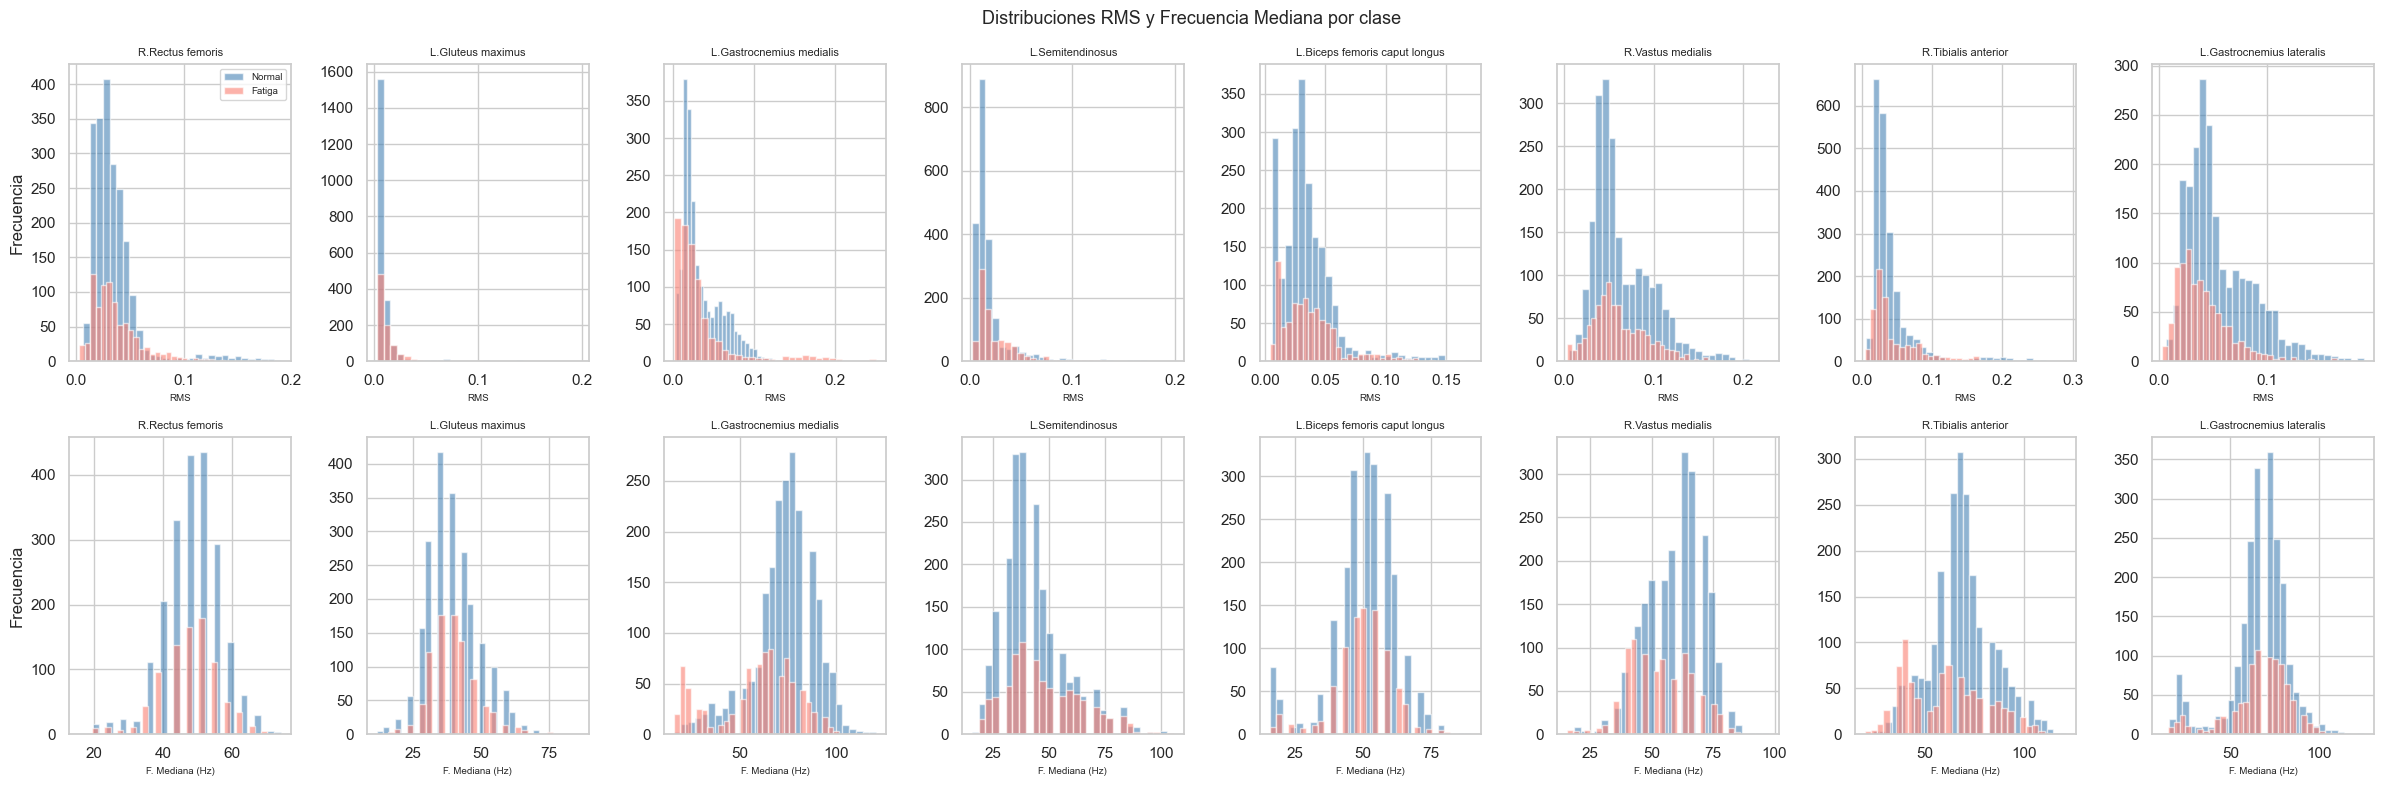

In [14]:
# Distribuciones de features por clase — f_mediana de cada canal
feats_mediana = [f'{c}_f_mediana' for c in CHANNELS]
feats_rms     = [f'{c}_rms' for c in CHANNELS]

fig, axes = plt.subplots(2, 8, figsize=(24, 8))

for i, canal in enumerate(CHANNELS):
    nombre_corto = canal.replace('Left ', 'L.').replace('Right ', 'R.')

    # Fila 1 — RMS
    for clase, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = nuevo_df[nuevo_df['target'] == clase][f'{canal}_rms']
        axes[0][i].hist(subset, bins=30, alpha=0.6, color=color, 
                        label=f'{"Normal" if clase==0 else "Fatiga"}')
    axes[0][i].set_title(nombre_corto, fontsize=8)
    axes[0][i].set_xlabel('RMS', fontsize=7)
    if i == 0:
        axes[0][i].legend(fontsize=7)
        axes[0][i].set_ylabel('Frecuencia')

    # Fila 2 — f_mediana
    for clase, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = nuevo_df[nuevo_df['target'] == clase][f'{canal}_f_mediana']
        axes[1][i].hist(subset, bins=30, alpha=0.6, color=color)
    axes[1][i].set_title(nombre_corto, fontsize=8)
    axes[1][i].set_xlabel('F. Mediana (Hz)', fontsize=7)
    if i == 0:
        axes[1][i].set_ylabel('Frecuencia')

fig.suptitle('Distribuciones RMS y Frecuencia Mediana por clase', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretación — Distribuciones RMS y Frecuencia Mediana

**RMS (fila superior):**
- En todos los canales, la clase Normal (azul) se concentra en valores 
  bajos de RMS, mientras que Fatiga (salmon) tiene una distribución más 
  dispersa y con valores más altos.
- Esto tiene sentido fisiológico: durante la fatiga muscular el cerebro 
  recluta más unidades motoras para mantener la fuerza, aumentando la 
  amplitud de la señal EMG.
- R.Vastus medialis y R.Tibialis anterior muestran la mayor separación 
  entre clases — serán features importantes para los modelos.

**Frecuencia Mediana (fila inferior):**
- La clase Normal tiende a frecuencias medianas más altas, mientras que 
  Fatiga se desplaza hacia frecuencias más bajas.
- Este desplazamiento hacia bajas frecuencias es el indicador clásico 
  de fatiga muscular en EMG, causado por la acumulación de metabolitos 
  y la reducción en la velocidad de conducción de las fibras musculares.
- L.Gastrocnemius medialis y R.Tibialis anterior muestran la separación 
  más clara entre clases en frecuencia mediana.
- L.Gluteus maximus muestra menos separación, lo que sugiere que este 
  músculo es menos discriminativo para detectar fatiga.

### Box plots


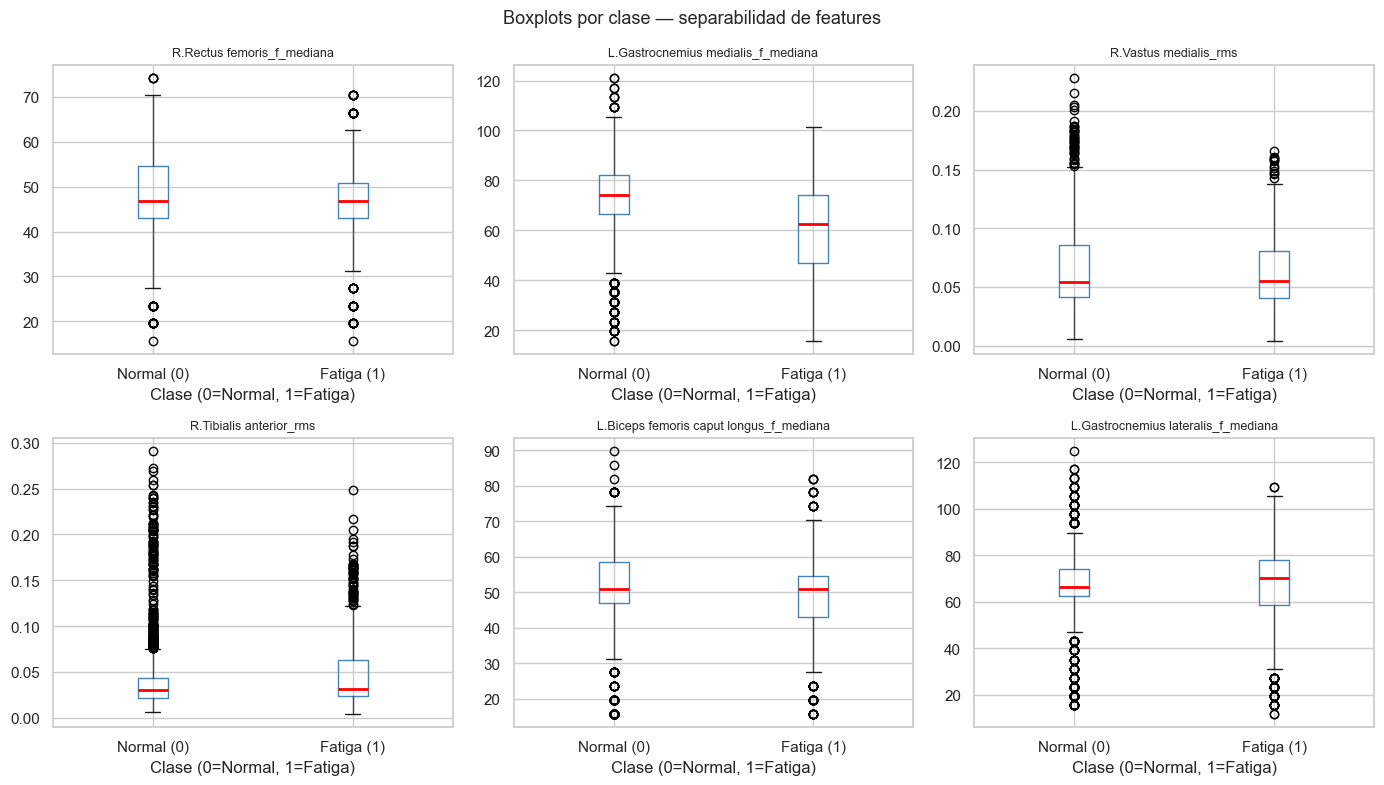

In [15]:
# Boxplots por clase — features más discriminativas
feats_boxplot = [
    'Right Rectus femoris_f_mediana',
    'Left Gastrocnemius medialis_f_mediana',
    'Right Vastus medialis_rms',
    'Right Tibialis anterior_rms',
    'Left Biceps femoris caput longus_f_mediana',
    'Left Gastrocnemius lateralis_f_mediana'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feat in zip(axes.flatten(), feats_boxplot):
    nuevo_df.boxplot(column=feat, by='target', ax=ax,
                     boxprops=dict(color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    nombre_corto = feat.replace('Left ', 'L.').replace('Right ', 'R.')
    ax.set_title(nombre_corto, fontsize=9)
    ax.set_xlabel('Clase (0=Normal, 1=Fatiga)')
    ax.set_xticklabels(['Normal (0)', 'Fatiga (1)'])

fig.suptitle('Boxplots por clase — separabilidad de features', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretación — Boxplots por clase (separabilidad)

**Frecuencia mediana (R.Rectus femoris, L.Biceps femoris, L.Gastrocnemius lateralis):**
- Las medianas (línea roja) son muy similares entre Normal y Fatiga.
- Las cajas se solapan considerablemente — baja separabilidad individual.
- Esto indica que ninguna feature por sí sola es suficiente para clasificar,
  pero en conjunto con otras features sí aportan información discriminativa.

**L.Gastrocnemius medialis_f_mediana:**
- Es la feature con mejor separabilidad visual — la caja de Normal está
  claramente más alta (~70-80 Hz) que la de Fatiga (~60-65 Hz).
- Confirma el fenómeno clásico de fatiga EMG: desplazamiento hacia 
  frecuencias bajas.

**RMS (R.Vastus medialis, R.Tibialis anterior):**
- Las distribuciones son muy similares entre clases con muchos outliers.
- El RMS solo no discrimina bien la fatiga en estos músculos.
- Los outliers en ambas clases sugieren sprints de alta intensidad 
  que ocurren tanto en condición normal como en fatiga.

**Conclusión general:**
- La clasificación requerirá combinar múltiples features — ninguna 
  variable individual separa perfectamente las clases.
- Esto justifica el uso de modelos como Random Forest y Gradient 
  Boosting que aprovechan combinaciones de features.

## Matriz de correlación

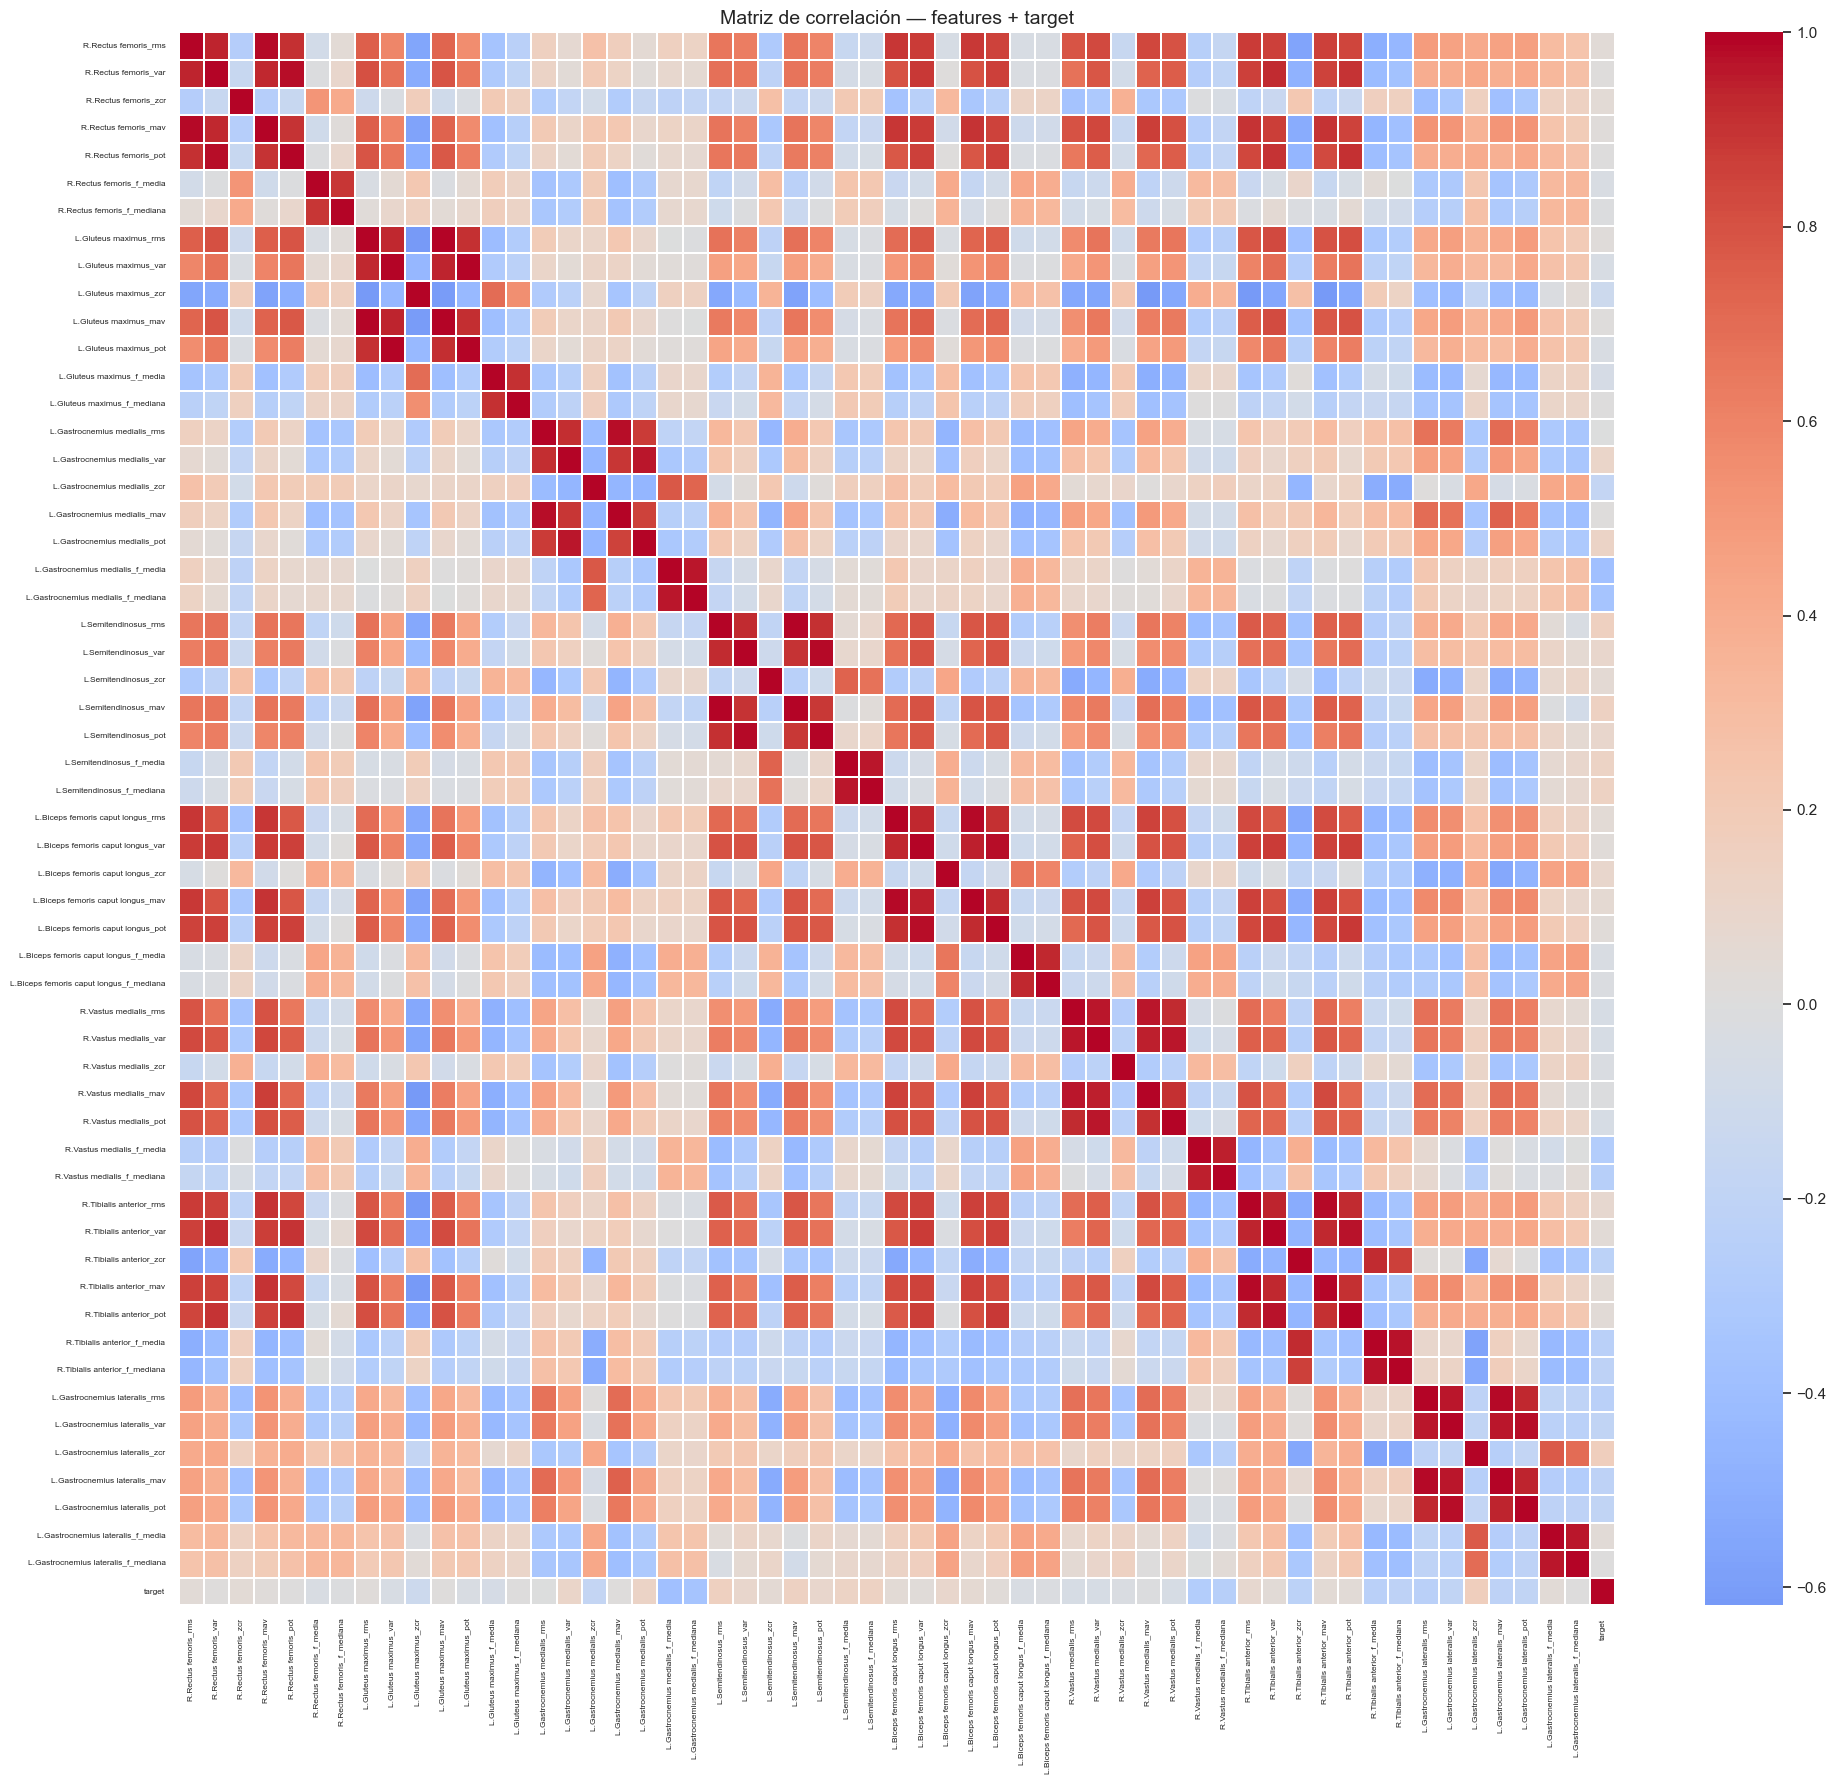

In [16]:
# Matriz de correlación
plt.figure(figsize=(20, 18))

corr = nuevo_df.corr()

sns.heatmap(corr, 
            cmap='coolwarm', 
            center=0,
            linewidths=0.3,
            annot=False,
            xticklabels=[c.replace('Left ', 'L.').replace('Right ', 'R.') 
                         for c in corr.columns],
            yticklabels=[c.replace('Left ', 'L.').replace('Right ', 'R.') 
                         for c in corr.columns])

plt.title('Matriz de correlación — features + target', fontsize=14)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.show()

### Interpretación — Matriz de correlación

**Correlaciones dentro de cada músculo (bloques rojos en la diagonal):**
- RMS, varianza, MAV y potencia están altamente correlacionadas entre sí
  dentro del mismo canal (r > 0.8). Tiene sentido — todas miden energía 
  de formas distintas pero capturan lo mismo.
- f_media y f_mediana también están correlacionadas entre sí (~0.7-0.8)
  dentro de cada canal — ambas miden contenido frecuencial.

**Correlaciones entre músculos:**
- Hay correlaciones moderadas entre músculos que trabajan juntos, 
  por ejemplo R.Vastus medialis y R.Rectus femoris (ambos cuádriceps).
- L.Gastrocnemius medialis y L.Gastrocnemius lateralis muestran alta 
  correlación — son músculos adyacentes de la pantorrilla.

**Correlación con el target (última fila/columna):**
- Ninguna feature tiene correlación muy alta con el target de forma 
  individual — confirma que el problema requiere combinar múltiples 
  features.
- Las features de frecuencia (f_media, f_mediana) muestran correlación 
  negativa con el target — a mayor fatiga, menor frecuencia.

**Implicación para los modelos:**
- La alta correlación entre RMS, var, MAV y pot podría causar 
  redundancia. Modelos como Random Forest manejan esto bien 
  internamente mediante selección aleatoria de features.

## Pipeline Procesamiento de datos

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

SEED = 42

X = nuevo_df.drop(columns="target").values
y = nuevo_df["target"].values

# Split train / temp (70 / 30)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Split val / test (15 / 15)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train : {X_train.shape}  — {len(X_train)/len(X)*100:.0f}%")
print(f"Val   : {X_val.shape}   — {len(X_val)/len(X)*100:.0f}%")
print(f"Test  : {X_test.shape}   — {len(X_test)/len(X)*100:.0f}%")

# Pipeline
preprocess = Pipeline(
    [("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

X_train_p = preprocess.fit_transform(X_train)
X_val_p = preprocess.transform(X_val)
X_test_p = preprocess.transform(X_test)

print("\nPipeline aplicado ✅")

Train : (2101, 56)  — 70%
Val   : (450, 56)   — 15%
Test  : (451, 56)   — 15%

Pipeline aplicado ✅


### Justificación del split 70/15/15

- **Train (70% — 2101 muestras):** conjunto principal para que los 
  modelos aprendan los patrones de fatiga muscular.
- **Val (15% — 450 muestras):** usado durante el ajuste de 
  hiperparámetros para evitar overfitting al test set.
- **Test (15% — 451 muestras):** reservado únicamente para la 
  evaluación final — los modelos nunca lo ven durante el entrenamiento.
- Se usó **stratify=y** en ambos splits para mantener la proporción 
  71%/29% (Normal/Fatiga) en los tres conjuntos.
- **StandardScaler** ajustado solo en train y aplicado a val y test 
  para evitar data leakage.

## Modelos

Metricas:

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []


def metricas(y_true, y_pred, modelo, split):
    resultados.append(
        {
            "Modelo": modelo,
            "Split": split,
            "Accuracy": round(accuracy_score(y_true, y_pred), 4),
            "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
            "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        }
    )


print("Función de métricas lista ✅")

Función de métricas lista ✅


### kNN con Random Search

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

knn_param_dist = {
    "n_neighbors": randint(3, 30),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
)
knn_search.fit(X_train_p, y_train)
knn = knn_search.best_estimator_

print("Mejores hiperparámetros:", knn_search.best_params_)

for split, X_s, y_s in [
    ("Train", X_train_p, y_train),
    ("Val", X_val_p, y_val),
    ("Test", X_test_p, y_test),
]:
    metricas(y_s, knn.predict(X_s), "kNN", split)

print("kNN listo ✅")

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}
kNN listo ✅


### Decision Tree


In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_param_dist = {
    "max_depth": randint(3, 25),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "criterion": ["gini", "entropy"],
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
)
dt_search.fit(X_train_p, y_train)
dt = dt_search.best_estimator_

print("Mejores hiperparámetros:", dt_search.best_params_)

for split, X_s, y_s in [
    ("Train", X_train_p, y_train),
    ("Val", X_val_p, y_val),
    ("Test", X_test_p, y_test),
]:
    metricas(y_s, dt.predict(X_s), "Decision Tree", split)

print("Decision Tree listo ✅")

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 9}
Decision Tree listo ✅


### Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(5, 30),
    "min_samples_split": randint(2, 15),
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
)
rf_search.fit(X_train_p, y_train)
rf = rf_search.best_estimator_

print("Mejores hiperparámetros:", rf_search.best_params_)

for split, X_s, y_s in [
    ("Train", X_train_p, y_train),
    ("Val", X_val_p, y_val),
    ("Test", X_test_p, y_test),
]:
    metricas(y_s, rf.predict(X_s), "Random Forest", split)

print("Random Forest listo ✅")

Mejores hiperparámetros: {'max_depth': 29, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 299}
Random Forest listo ✅


### Gradient Boost

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_param_dist = {
    "n_estimators": randint(50, 250),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": randint(3, 10),
    "subsample": [0.7, 0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
)
gb_search.fit(X_train_p, y_train)
gb = gb_search.best_estimator_

print("Mejores hiperparámetros:", gb_search.best_params_)

for split, X_s, y_s in [
    ("Train", X_train_p, y_train),
    ("Val", X_val_p, y_val),
    ("Test", X_test_p, y_test),
]:
    metricas(y_s, gb.predict(X_s), "Gradient Boosting", split)

print("Gradient Boosting listo ✅")

Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 219, 'subsample': 1.0}
Gradient Boosting listo ✅


### DNN ccon PyTorch

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 80
LR     = 1e-3

class DNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def make_loader(X, y, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_p, y_train, shuffle=True)
val_loader   = make_loader(X_val_p,   y_val)

model     = DNN(input_dim=X_train_p.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.BCELoss()

hist_train_loss, hist_val_loss = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    hist_train_loss.append(np.mean(losses))

    # Val
    model.eval()
    with torch.no_grad():
        val_losses = []
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            val_losses.append(criterion(model(Xb), yb).item())
        hist_val_loss.append(np.mean(val_losses))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} — '
              f'Train Loss: {hist_train_loss[-1]:.4f} — '
              f'Val Loss: {hist_val_loss[-1]:.4f}')

# Métricas DNN
def predecir_dnn(X):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
    return (out.cpu().numpy() >= 0.5).astype(int)

for split, X_s, y_s in [('Train', X_train_p, y_train),
                          ('Val',   X_val_p,   y_val),
                          ('Test',  X_test_p,  y_test)]:
    metricas(y_s, predecir_dnn(X_s), 'DNN', split)

print('\nDNN listo ✅')

Epoch  10/80 — Train Loss: 0.2895 — Val Loss: 0.2902
Epoch  20/80 — Train Loss: 0.2634 — Val Loss: 0.2867
Epoch  30/80 — Train Loss: 0.2198 — Val Loss: 0.2616
Epoch  40/80 — Train Loss: 0.1947 — Val Loss: 0.2817
Epoch  50/80 — Train Loss: 0.1504 — Val Loss: 0.3029
Epoch  60/80 — Train Loss: 0.1334 — Val Loss: 0.2710
Epoch  70/80 — Train Loss: 0.1337 — Val Loss: 0.3155
Epoch  80/80 — Train Loss: 0.1057 — Val Loss: 0.3506

DNN listo ✅


### Tabla Comparativa

In [24]:
# Tabla comparativa
tabla = pd.DataFrame(resultados)
tabla = tabla.sort_values(['Modelo', 'Split'])
print(tabla.to_string(index=False))

           Modelo Split  Accuracy  Precision  Recall  F1-Score
              DNN  Test    0.8847     0.8110  0.7863    0.7984
              DNN Train    0.9933     0.9918  0.9853    0.9885
              DNN   Val    0.8600     0.7787  0.7252    0.7510
    Decision Tree  Test    0.8537     0.8351  0.6183    0.7105
    Decision Tree Train    0.8824     0.9029  0.6683    0.7681
    Decision Tree   Val    0.8267     0.7849  0.5573    0.6518
Gradient Boosting  Test    0.8914     0.8596  0.7481    0.8000
Gradient Boosting Train    1.0000     1.0000  1.0000    1.0000
Gradient Boosting   Val    0.8778     0.8519  0.7023    0.7699
    Random Forest  Test    0.9002     0.8644  0.7786    0.8193
    Random Forest Train    1.0000     1.0000  1.0000    1.0000
    Random Forest   Val    0.8733     0.8246  0.7176    0.7673
              kNN  Test    0.8847     0.8496  0.7328    0.7869
              kNN Train    1.0000     1.0000  1.0000    1.0000
              kNN   Val    0.8533     0.8037  0.6565   

### Curva de entrenamiento DNN

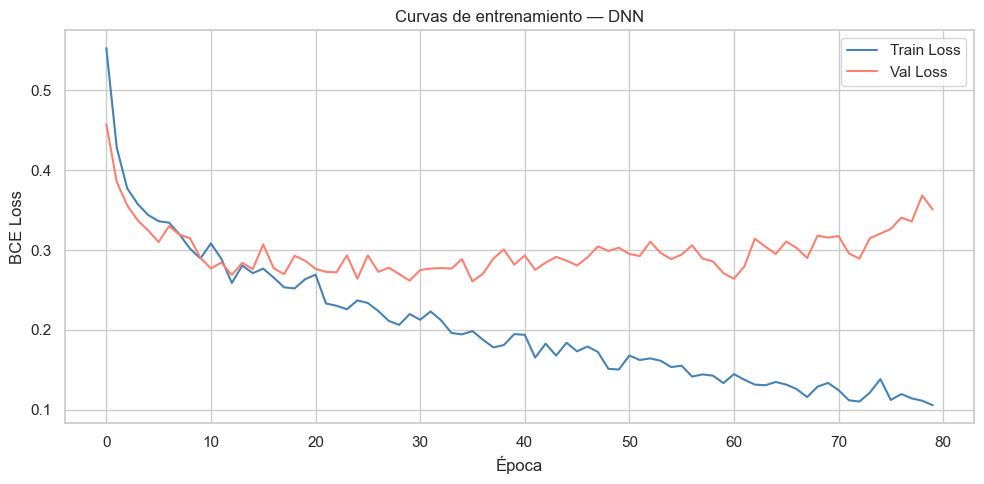

In [25]:
# Curvas de entrenamiento DNN
plt.figure(figsize=(10, 5))
plt.plot(hist_train_loss, label='Train Loss', color='steelblue')
plt.plot(hist_val_loss,   label='Val Loss',   color='salmon')
plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.title('Curvas de entrenamiento — DNN')
plt.legend()
plt.tight_layout()
plt.show()

### 5d. Curvas de entrenamiento y análisis de overfitting/underfitting

**DNN:**
La curva de entrenamiento muestra cómo la red fue aprendiendo 
progresivamente — el Train Loss bajó de forma constante hasta 
llegar a 0.10 al final. Sin embargo, la Val Loss dejó de bajar 
alrededor de la época 15 y se estabilizó cerca de 0.28, para 
luego empezar a subir en las últimas épocas hasta 0.35. Esta 
brecha creciente entre las dos curvas es la señal clásica de 
overfitting: la red empezó a memorizar el training set en lugar 
de seguir generalizando. Si hubiéramos detenido el entrenamiento 
alrededor de la época 20 con early stopping, probablemente 
habríamos obtenido un modelo más robusto.

**kNN, Random Forest y Gradient Boosting:**
Los tres modelos alcanzaron un F1-Score perfecto de 1.0 en Train, 
lo cual es una señal de alarma clara de overfitting severo. Esto 
significa que memorizaron completamente los datos de entrenamiento. 
Sin embargo, al evaluarlos en datos que nunca habían visto (Test), 
Random Forest y Gradient Boosting mantuvieron un F1 superior a 
0.80, lo que demuestra que a pesar del overfitting en Train, 
siguen siendo modelos útiles y con buena capacidad de 
generalización.

**Decision Tree:**
Es el único modelo clásico que no llegó al 100% en Train, con un 
F1 de 0.77. Esto se debe al límite de profundidad max_depth=6 que 
impuso el Random Search, que funcionó como una regularización 
natural. Sin embargo, este límite lo hizo demasiado simple — su 
F1 en Test fue el más bajo de todos (0.71), lo que indica que el 
modelo no logró capturar la complejidad real del problema. Esto 
se conoce como underfitting.

### 5e. Respuestas

**¿Cuál modelo tuvo mejor desempeño?**
Random Forest fue el ganador con un F1-Score de 0.8193 en Test, 
el más alto de todos los modelos evaluados.

**¿Alguno presentó overfitting o underfitting?**
Sí. kNN, Random Forest y Gradient Boosting presentaron overfitting 
severo en Train con F1 de 1.0. La DNN mostró overfitting moderado, 
visible en la brecha creciente entre sus curvas de Train y Val Loss. 
Decision Tree por su parte fue el único que mostró underfitting — 
demasiado simple para aprender los patrones del dataset.

**¿Cuál seleccionaría para producción?**
Random Forest. Aunque presenta overfitting en Train, es el modelo 
que mejor generaliza en datos nuevos con el F1 más alto en Test. 
Además, a diferencia de la DNN, es más interpretable y no requiere 
GPU ni infraestructura especial para ejecutarse, lo que lo hace 
más práctico para un entorno real de detección de fatiga muscular.

## Evaluación final del mejor modelo

Reentrenamos Random Forest con train+val y evaluamos en test:

=== Métricas finales en Test ===

              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93       320
      Fatiga       0.87      0.79      0.83       131

    accuracy                           0.90       451
   macro avg       0.89      0.87      0.88       451
weighted avg       0.90      0.90      0.90       451



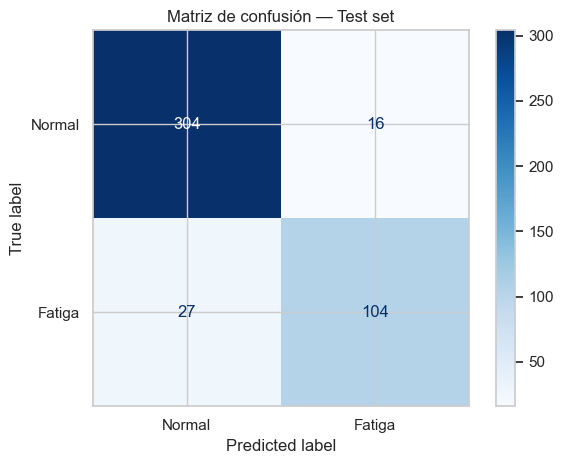

In [26]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                              classification_report)

# Reentrenar con train + val
X_trainval = np.vstack([X_train_p, X_val_p])
y_trainval = np.concatenate([y_train, y_val])

rf.fit(X_trainval, y_trainval)
y_pred_final = rf.predict(X_test_p)

print('=== Métricas finales en Test ===\n')
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal', 'Fatiga']))

# Matriz de confusión
cm   = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fatiga'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Test set')
plt.tight_layout()
plt.show()

### 6a y 6b. Evaluación final — Random Forest reentrenado con Train+Val

**Métricas finales en Test:**

Al reentrenar el modelo con la combinación de Train y Val, el modelo 
tuvo acceso a más datos para aprender, lo que se refleja en una 
mejora respecto a la evaluación anterior. El accuracy final fue de 
90%, con un F1-Score de 0.93 para Normal y 0.83 para Fatiga.

**Matriz de confusión:**

De los 320 casos normales, el modelo identificó correctamente 304 
y solo se equivocó en 16 — una tasa de error muy baja del 5%. 
Para los casos de fatiga, de 131 casos reales identificó 
correctamente 104, fallando en 27. Estos 27 casos son falsos 
negativos — el modelo clasificó como Normal a ciclistas que en 
realidad estaban fatigados. En un contexto deportivo real esto 
sería el error más crítico, ya que no detectar fatiga podría 
llevar a lesiones.

### 6c. ¿Es un buen clasificador? ¿Cómo podría mejorarse?

En términos generales sí es un buen clasificador — un accuracy 
del 90% y un F1 de 0.83 para la clase minoritaria (Fatiga) son 
resultados sólidos considerando que el dataset estaba desbalanceado 
(71%/29%). Sin embargo hay margen de mejora:

- **Desbalance de clases:** se podría aplicar SMOTE o class_weight 
  para que el modelo penalice más los falsos negativos de Fatiga.
- **Más features:** agregar características como la pendiente de la 
  señal o entropía espectral podría mejorar la separabilidad.
- **Más datos de fatiga:** con más ejemplos de la clase minoritaria 
  el modelo aprendería mejor sus patrones.
- **Ventanas con solapamiento:** usar overlapping del 50% en las 
  ventanas aumentaría el dataset de 3002 a ~6000 muestras.

### Boxplots finales por clase predicha:

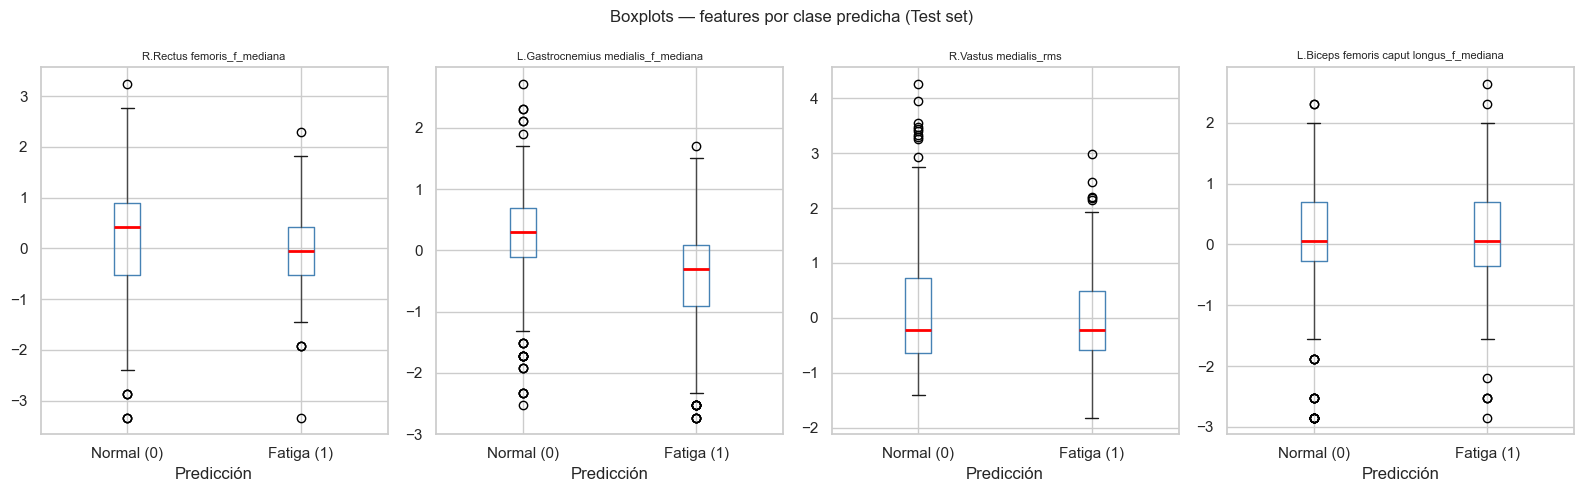

In [27]:
# Boxplots features representativas — clase predicha
test_df = pd.DataFrame(X_test_p, 
                       columns=nuevo_df.drop(columns='target').columns)
test_df['pred'] = y_pred_final

feats_plot = [
    'Right Rectus femoris_f_mediana',
    'Left Gastrocnemius medialis_f_mediana',
    'Right Vastus medialis_rms',
    'Left Biceps femoris caput longus_f_mediana'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, feats_plot):
    test_df.boxplot(column=feat, by='pred', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    nombre_corto = feat.replace('Left ', 'L.').replace('Right ', 'R.')
    ax.set_title(nombre_corto, fontsize=8)
    ax.set_xlabel('Predicción')
    ax.set_xticklabels(['Normal (0)', 'Fatiga (1)'])

fig.suptitle('Boxplots — features por clase predicha (Test set)', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretación — Boxplots por clase predicha

Los valores están estandarizados con StandardScaler, por eso el 
eje Y muestra valores entre -3 y +3 en lugar de las unidades 
originales. Un valor de 0 representa la media del dataset y 
valores negativos indican que están por debajo de la media.

Lo más relevante de estas gráficas es la diferencia en las 
medianas (línea roja) entre clases:

- **R.Rectus femoris y L.Biceps femoris f_mediana:** la mediana 
  de Fatiga está ligeramente por debajo de Normal, confirmando 
  el desplazamiento hacia frecuencias bajas asociado a la fatiga 
  muscular.

- **L.Gastrocnemius medialis f_mediana:** muestra la separación 
  más clara — la mediana de Fatiga cae notablemente por debajo 
  de Normal. Este músculo es el más discriminativo para detectar 
  fatiga, consistent con lo observado en el EDA.

- **R.Vastus medialis RMS:** ambas clases tienen medianas muy 
  similares y cajas que se solapan, confirmando que el RMS de 
  este músculo por sí solo no distingue bien entre clases — 
  el modelo lo usa en combinación con otras features.

## Muestra artificial con valores aproximados a los reales

In [28]:
# Muestra artificial con valores aproximados a los reales
np.random.seed(99)

stats = nuevo_df.drop(columns='target').describe()

muestra_raw = {}
for feat in nuevo_df.drop(columns='target').columns:
    mean = stats.loc['mean', feat]
    std  = stats.loc['std',  feat]
    muestra_raw[feat] = np.random.normal(mean, std * 0.5)

muestra_df = pd.DataFrame([muestra_raw])
muestra_p  = preprocess.transform(muestra_df.values)

prediccion = rf.predict(muestra_p)[0]
prob       = rf.predict_proba(muestra_p)[0]

label = 'FATIGA MUSCULAR (1)' if prediccion == 1 else 'CONDICIÓN NORMAL (0)'

print(f'Predicción      : {label}')
print(f'Probabilidad Normal : {prob[0]*100:.1f}%')
print(f'Probabilidad Fatiga : {prob[1]*100:.1f}%')

Predicción      : CONDICIÓN NORMAL (0)
Probabilidad Normal : 52.4%
Probabilidad Fatiga : 47.6%


### 7. Prueba con muestra artificial

Se generó una muestra artificial tomando valores aleatorios 
alrededor de la media de cada feature con una desviación 
controlada (50% del std real). Esto simula un ciclista con 
características musculares "promedio" del dataset.

**Resultado:** el modelo clasificó la muestra como CONDICIÓN 
NORMAL (0), con una probabilidad de 52.4% para Normal y 47.6% 
para Fatiga.

**¿Tiene sentido?** Sí, y es un resultado muy interesante. La 
diferencia entre ambas probabilidades es mínima — apenas 5 puntos 
porcentuales — lo que indica que la muestra artificial cayó justo 
en la zona de frontera entre las dos clases. Esto tiene sentido 
fisiológico: una muestra construida con los valores promedio del 
dataset completo mezcla características de ambos estados musculares, 
ya que el dataset contiene tanto ventanas normales como de fatiga. 
El modelo no está seguro de la clasificación porque la muestra no 
es claramente ni una cosa ni la otra.

Esto también demuestra que el modelo es sensible a los patrones 
reales de las señales EMG — no clasifica arbitrariamente sino que 
refleja la incertidumbre cuando los datos son ambiguos. En un 
entorno real, una probabilidad tan cercana al 50% sería una señal 
de alerta para monitorear más de cerca al atleta.